# Ball & Beam: System Analysis

Key Python commands used in this tutorial are:
[`control.TransferFunction`](https://python-control.readthedocs.io/en/latest/generated/control.TransferFunction.html),
[`control.pzmap`](https://python-control.readthedocs.io/en/latest/generated/control.pzmap.html),
[`control.step_response`](https://python-control.readthedocs.io/en/latest/generated/control.step_response.html)

## System model

The transfer function from the gear angle ($\theta(s)$) to the ball position ($R(s)$), as derived in the [Ball & Beam: System Modeling](BallBeam_SystemModeling.ipynb) page.

$$ P(s) = \frac{R(s)}{\Theta(s)} = -\frac{mgd}{L \left(\frac{J}{R^2}+m\right)} \frac{1}{s^2} \qquad [ \frac{m}{rad} ]$$

Open a new code cell and add the following code to create a transfer function model in Python.



In [1]:
import control
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(
    rc={
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "figure.figsize": (4 * 1.618, 4),
        "figure.dpi": 200,
    }
)

m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6

s = control.TransferFunction.s
P_ball = -m * g * d / L / (J / R**2 + m) / s**2
P_ball

TransferFunction(
array([0.21]),
array([1, 0, 0]),
outputs=1, inputs=1)

## Pole/zero map

The Ball and Beam system is a type II system which has two poles at the origin, as seen in the pole/zero map below. Since the poles are not strictly in the left half plane, the open loop system will be unstable as seen in the step response below.



/projects/UMich_Controls_Tutorials_Python/venv_UMich_Controls_Tutorials_Python/lib/python3.12/site-packages/control/pzmap.py:327: FutureWarning: pole_zero_plot() return value of poles, zeros is deprecated; use pole_zero_map()
  warnings.warn(


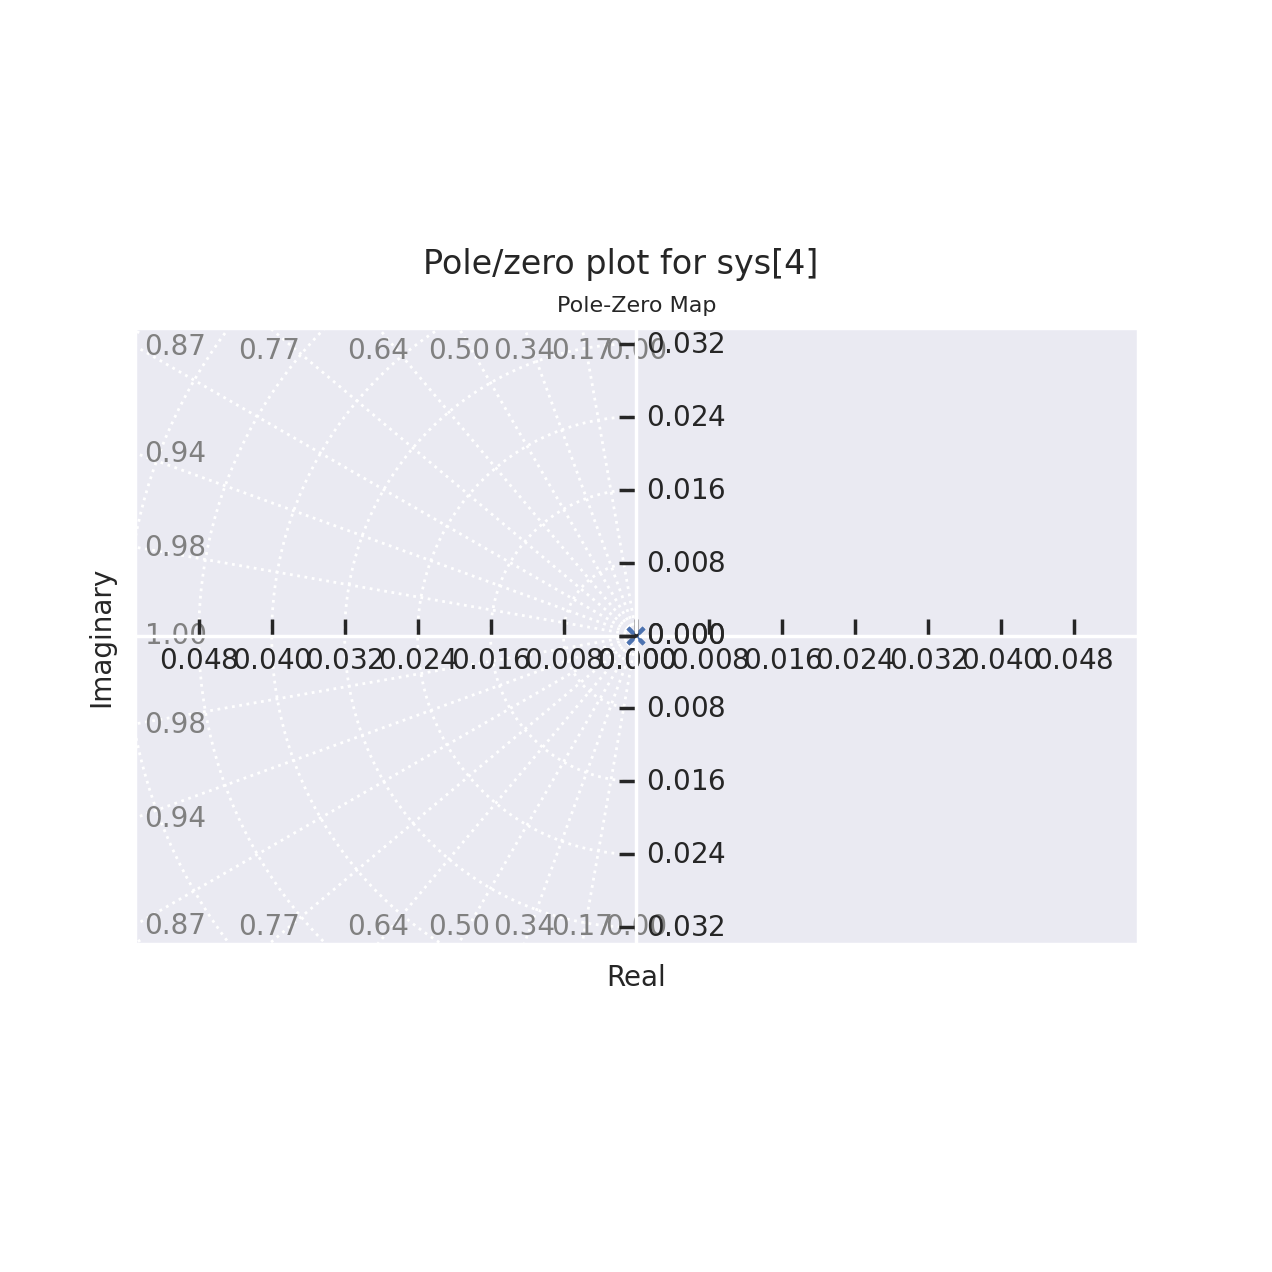

In [2]:
control.pzmap(P_ball, plot=True, grid="on")
plt.title("Pole-Zero Map")
plt.show()

## Open-loop step response

Now, we would like to observe the ball's response to a step input on the motor servo gear angle theta (1-radian step). To do this you will need to add the following line to your code cell.



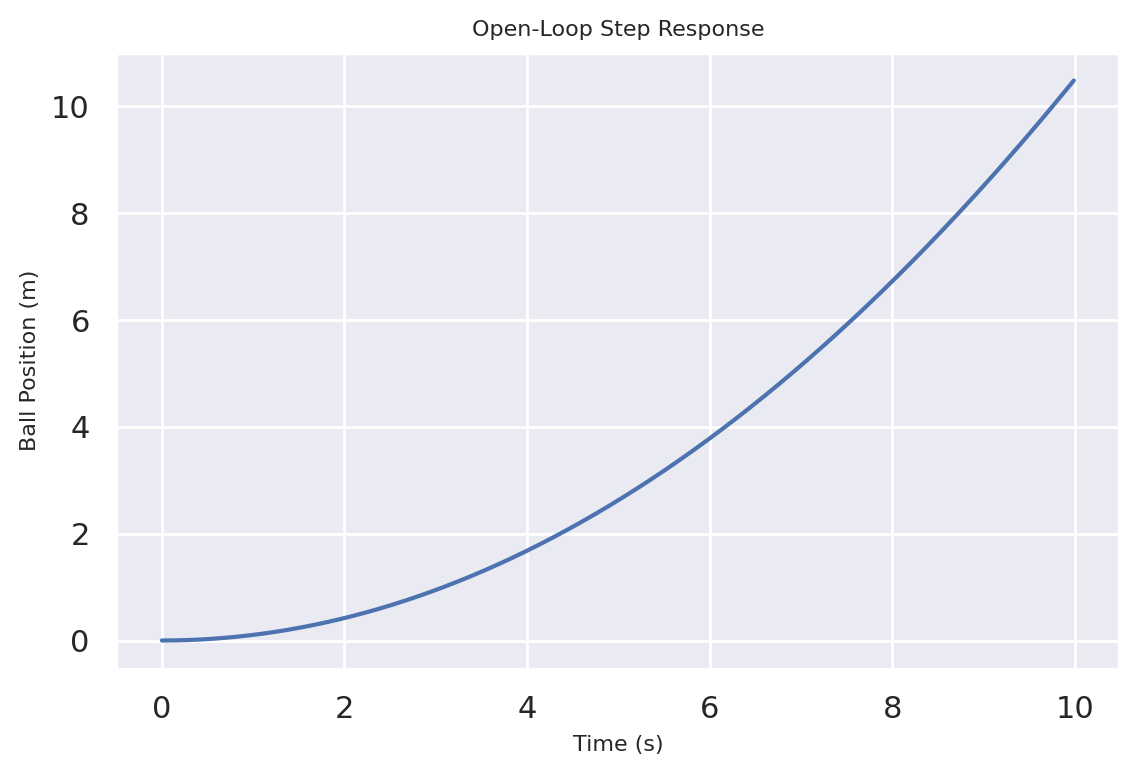

In [3]:
t = np.arange(0, 10, 0.01)
T, yout = control.step_response(P_ball, T=t)
plt.plot(T, yout)
plt.title("Open-Loop Step Response")
plt.xlabel("Time (s)")
plt.ylabel("Ball Position (m)")
plt.grid("on")
plt.show()

From this plot it is clear that the system is unstable in open-loop causing the ball to roll right off the end of the beam. Therefore, some method of controlling the ball's position in this system is required. Several examples of controller design are provided in these tutorials to address this problem.

